# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#import re

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
# Cantidad de valores nulos
print(users.isna().sum())
# Proporción de valores nulos
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
# Cantidad de valores nulos
print(usage.isna().sum())
# Proporción de valores nulos
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

***Valores nulos***  
**¿Qué columnas tienen valores faltantes y en qué proporción?**
- __Para users las columnas de: city__ con 469 de 4000 el 11.7% aproximadamente y __churn_date__ con 3534 de 4000 el 88.3% aproximadamente.

- __Para usage las columnas de: date__ con 50 de 40000 el 0.1% aproximadamente, no llega al 1%, __duration__ con 22076 de 40000 el 55.2% aproximadamente y __length__ con 17896 de 40000 el 44.7% aproximadamente.
  
**Indica qué harías: ¿imputar, eliminar, ignorar?**
- __En el caso de las columnas de users:__
- __city:__ En este caso se tiene un 11.7% aproximadamente de error o nulos, y es la variable de ciudades, se tienen la mayoría de los conteos de ciudades, por el tipo de dato, salvo previa consulta, mantendría los nulos.
- __churn_date:__ Esta es básicamente la fecha en que se ha dado de baja algún cliente, tiene de error o nulos un 88.3% aproximadamente, por lo que podría ignorarse para el  análisis.
  
- __En el caso de las columnas de usage:__
- __date:__ con 50 de 40000 tiene el 0.1% aproximadamente de error o faltantes por lo que se pueden ignorar esos registros nulos o faltantes, ya que tedrían un impacto minúsculo para el análisis.
- __duration:__ con 22076 de 40000 el 55.2% aproximadamente de error o faltantes (un alto porcentaje), lleva el registro de la duración de las llamadas, es recomendable indagar más sobre el tipo de valores ausentes o missingness que tiene.
- __length:__ con 17896 de 40000 el 44.7% aproximadamente de error o faltantes (un alto porcentaje), lleva el registro de la longitud en carácteres de los mensajes, es recomendable indagar más sobre el tipo de valores ausentes o missingness que tiene.


### 2.2 Detección de valores inválidos y sentinels


🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene una distribución estandar o normal, no se observan sesgos o casos especiales, la media y la mediana tienen rangos similares, la numeración empieza en un rango alto, pero esto parece ser debido a reglas o definiciones de la empresa.
- La columna `age` tiene outliers con tendencia a la izquierda, pero parecen deberse a valores sentinels o valores imposibles en la edad de los usuarios, por lo que habría que aplicar un proceso de limpieza y volver a verificar las estadisticas.

In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `duration` y `length` presentan un sesgo a la derecha o cola a la derecha (Right-skewed), la primera maneja la duración de las llamadas y la segunda la longitud de los mensajes, por lo que se puede deducir que en el caso de las llamadas puede haber algunas que tengan una larga duración y en el caso de los mensajes se puede observar que hay algunos mensajes muy largos a nivel de carácteres.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tiene 7 ciudades diferentes que entre todas aparecen 3531 veces, siendo Bogotá la ciudad top con una frecuencia de aparición de 808 veces.
- La columna `plan` tiene 2 planes diferentes que aparecen 4000 veces, siendo el plan básico el top más utilizado por poco con una frecuencia de aparición de 2595 veces.

In [16]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene 2 tipos de servicios el de llamada y el de mensaje de texto que entre los dos aparecen 40000 veces, siendo text(el mensaje de texto) la moda por poco con una frecuencia de aparición de 22092 veces.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Encontre valores invalidos o sentinels __en la columna age de users.__
- ¿Qué acción tomarías?
- Aplicaría un proceso de limpieza y volvería a verificar las estadisticas, revisaría la posibilidad de winsorizar o capar el valor minimo con base en las politicas de la edad minima para proporcionar el servicio a una persona.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='ignore')

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='ignore')

In [19]:
# Revisar los años presentes en `reg_date` de users
#pd.to_datetime(users['reg_date']).dt.year == 2024
#pd.to_datetime(users['reg_date']).dt.year.unique()
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se puede observar que se tienen registrados los años 2022, 2023, 2024 y 2026, siendo el 2026 un año que no ha transcurrido aún.

In [20]:
# Revisar los años presentes en `date` de usage
#pd.to_datetime(usage['date']).dt.year.unique()
#usage['date'].dt.year.sum()
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date` de __usage__, se puede observar solo el año 2024 y valores nan.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- En el año de reg_date de users aparece el 2026 un año que todavía no ha transcurrido.
- En el año de date de usage solo aparace el año 2024.
- ¿Qué harías con ellas?
- Para tener una muestra que permita trabajar con ambas tablas, lo mas recomendable o adecuado sería tomar el año 2024 para realizar el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, pd.NA)
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar "?" por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
#'''usage["duration"].isna().groupby(usage["type"]).mean() \
#     .sort_values(ascending=False) \
#     .head(10)'''
usage["duration"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)
#Forma extendida de la instrucción anterior.
#usage.groupby("type")["length"].apply(lambda x: x.isna().mean()) \
#     .sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquí y escribe tú diagnóstico de nulos sobre `duration` y `length`:
- La columna __type__ representa el tipo de servicio que se prestó, básicamente se tienen 2 servicios call(llamada) o text (mensaje de texto) y, además, al observar el conteo de nulos de __duration__(duración de la llamada) y __length__(longitud de texto en caracteres) se puede observar que tienen dependencia de __type__, por lo que se deduce que __son columnas con tipo de missingness MAR__.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 
Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage["minutos_llamada"] = usage["duration"].fillna(0)

# Tabla agregada por usuario calculando las columnas auxiliares de forma directa
#usage_agg = (
#    usage.groupby("user_id")
#         .agg(
#             cant_mensajes=("length", "count"),
#             cant_llamadas=("duration", "count"),
#             cant_minutos_llamada=("duration", "sum")
#         )
#         .reset_index()
#)

# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
         .agg({
             "is_text": "sum",
             "is_call": "sum",
             "minutos_llamada": "sum"
         })
         .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "minutos_llamada": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
#user_profile['plan'].describe()
user_profile["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

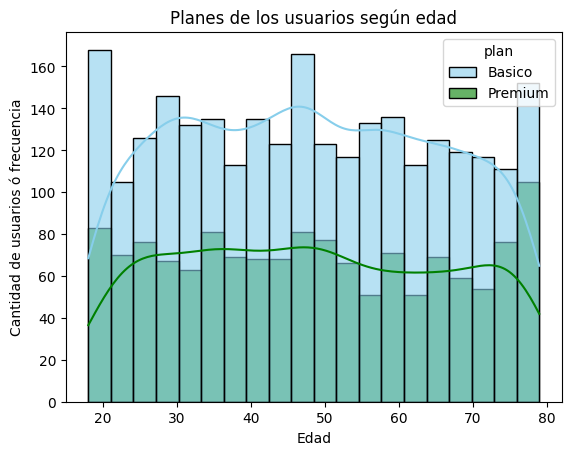

In [43]:
# Histograma para visualizar la edad (age)
#plt.figure(figsize=(10, 5))  # ancho=10, alto=5
sns.histplot(data=user_profile, x="age", hue="plan", bins=20, palette=["skyblue", "green"], kde=True, alpha=0.6)
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios ó frecuencia.')
plt.title('Planes de los usuarios según edad')
plt.show()

💡Insights: 
- Se tiene una distribución uniforme, la curva muestra un comportamiento casi uniforme, excepto por tres picos notables entre los 18 a 20 años, los 48 a 50 años y entre los 78 a 80 años (aproximadamente) en que el uso de los servicios del plan básico es mayor, además se observa un pico dominante entre los 78 a 80 en el uso de los servicios premium. No es una distribución normal, ni está sesgada es uniforme y se observan 4 segmentos claramente dominantes.

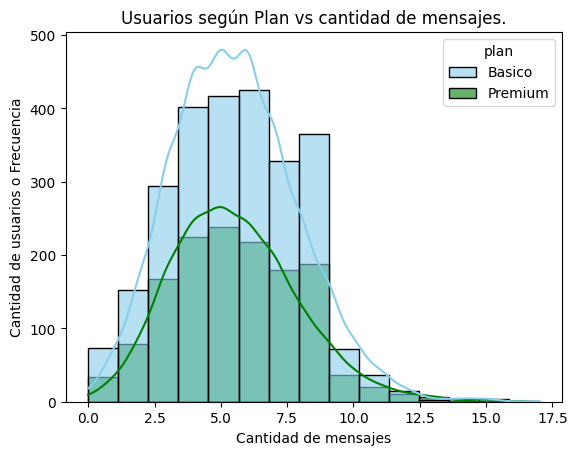

In [57]:
# Histograma para visualizar la cant_mensajes
#plt.figure(figsize=(10, 5))  # ancho=10, alto=5
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", bins=15, palette=["skyblue", "green"], kde=True, alpha=0.6)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios o Frecuencia')
plt.title('Usuarios según Plan vs cantidad de mensajes.')
plt.show()

💡Insights:
- Distribución sesgada a la derecha o Right-skewed, se puede observar como presenta una ligera cola a la derecha. Se observa que la mayoría de los usuarios en ambos planes en promedio enviaron 5.5 a 7 mensajes, siendo predominante en cuanto a cantidad de usuarios el plan básico.

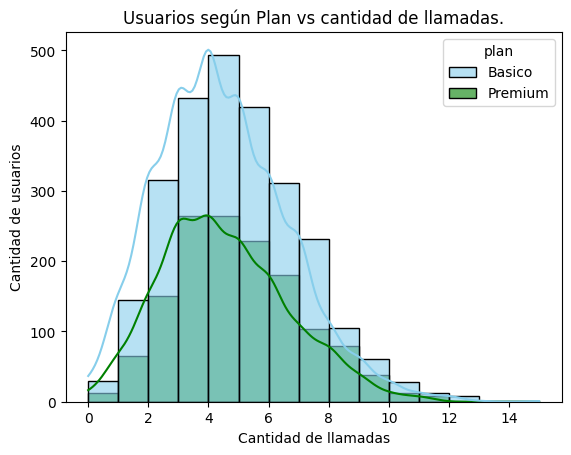

In [45]:
# Histograma para visualizar la cant_llamadas
#plt.figure(figsize=(10, 5))  # ancho=10, alto=5
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", bins=15, palette=["skyblue", "green"], kde=True, alpha=0.6)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Usuarios según Plan vs cantidad de llamadas.')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha o Right-skewed, se puede observar como presenta una ligera cola a la derecha. Se observa que la mayoría de los usuarios en ambos planes en promedio realizaron entre 4 a 5 llamadas, siendo predominante en cuanto a cantidad de usuarios el plan básico.

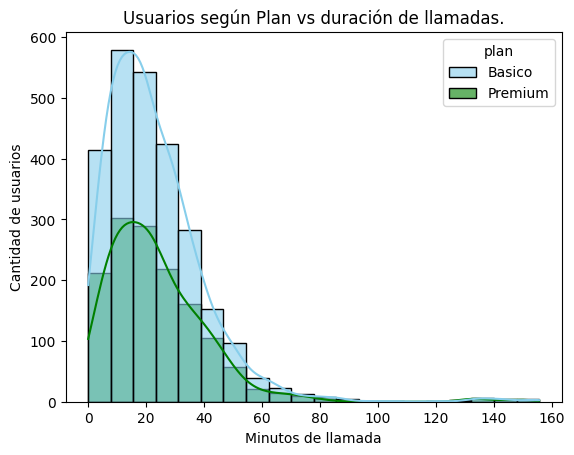

In [48]:
# Histograma para visualizar la cant_minutos_llamada
#plt.figure(figsize=(10, 5))  # ancho=10, alto=5

sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", bins=20, palette=["skyblue", "green"], kde=True, alpha=0.6)
plt.xlabel('Minutos de llamada')
plt.ylabel('Cantidad de usuarios')
plt.title('Usuarios según Plan vs duración de llamadas.')
plt.show()


💡Insights: 
- Distribución sesgada a la derecha o Right-skewed, se puede observar como presenta una cola a la derecha. Indica que la mayoría de las llamadas tanto en plan básico como premium tuvieron una duración promedio aproximada de entre 10 a 18 minutos y unas pocas estuvieron entre los 130 a 140 minutos aproximadamente.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.<br>
- Después de crear los gráficos, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.
    
**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

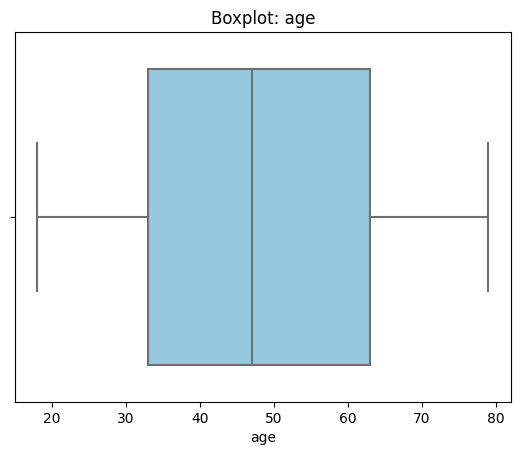

---------------------------------------------


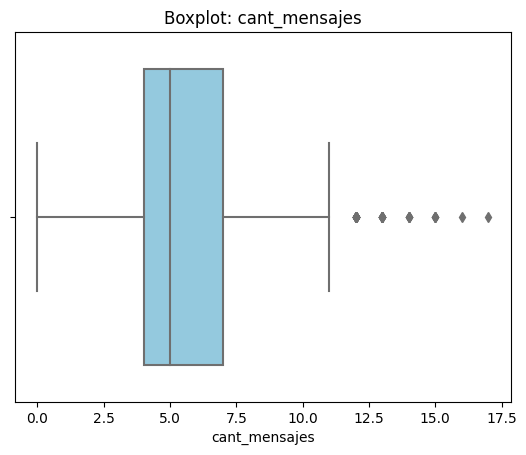

---------------------------------------------


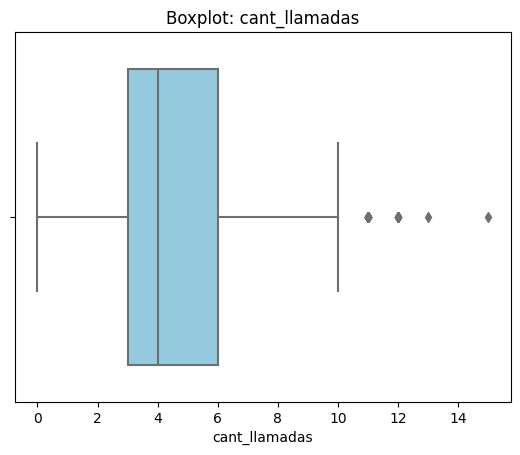

---------------------------------------------


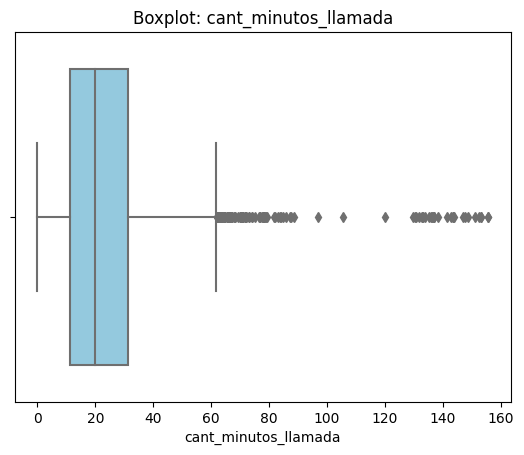

---------------------------------------------


In [62]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for colnum in columnas_numericas:
    # Graficar BoxPlot
    sns.boxplot(x=user_profile[colnum], color='skyblue')   
    # Etiquetas y título del gráfico
    plt.xlabel(colnum)    
    plt.title(f'Boxplot: {colnum}')
    #Mostrar Boxplot
    plt.show()
    print("---------------------------------------------")

💡Insights: 
- Age: no presenta outliers.
- cant_mensajes: presenta una pequeña cantidad de outliers.
- cant_llamadas: presenta una pequeña cantidad de outliers.
- cant_minutos_llamada: presenta una gran cantidad de outliers hasta casi 150 minutos.

In [31]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for colim in columnas_limites:    
    # ----- IQR -----
    # calcular Q1, Q3 e IQR
    Q1 = user_profile[colim].quantile(0.25)
    Q3 = user_profile[colim].quantile(0.75)
    IQR = Q3 - Q1
    # calcular límite superior, no se calcula el limite inferior, ya que no hay outliers del lado izquierdo
    #lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print("Limite superior de ", colim, ": ", upper)

Limite superior de  cant_mensajes :  11.5
Limite superior de  cant_llamadas :  10.5
Limite superior de  cant_minutos_llamada :  61.8575


In [32]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? los outliers están dentro de un rango manejable y mantenerlos reflejaría mejor el comportamiento de los clientes.
- cant_llamadas: mantener o no outliers, porqué? los outliers están dentro de un rango manejable y mantenerlos reflejaría mejor el comportamiento de los clientes.
- cant_minutos_llamada: mantener o no outliers, porqué?Todavía los outliers están dentro de un rango manejable y mantenerlos reflejaría mejor el comportamiento de los clientes, en este caso en especial el tener muchos outliers indica que a varios clientes les agrada hablar durante bastante tiempo, por lo que puede ser un caso que requiera mayor revisión, tal vez un area de oportunidad.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [35]:
# Crear columna grupo_uso en user profile
user_profile["grupo_uso"] = np.where( (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5), "Bajo uso",
                            np.where( (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10), "Uso medio",
                                      "Alto uso")
    )

# Crear columna grupo_uso forma alternativa
# Condiciones
#condiciones = [(user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
#               (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10)]
# Valores resultantes para cada condición
#grupos = ["Bajo uso", "Uso medio"]
# Crear la nueva columna
#user_profile["grupo_uso"] = np.select(condiciones, grupos, default="Alto uso")

In [36]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [37]:
# Crear columna grupo_edad
def crea_columna_grupo_edad(row):
    age = row['age']

    # Manejo de valores nulos/faltantes
    if pd.isna(age):
        return "Error en Datos"
    
    #Segmentación de Clientes Por Edad 
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile["grupo_edad"] = user_profile.apply(crea_columna_grupo_edad, axis=1)

In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

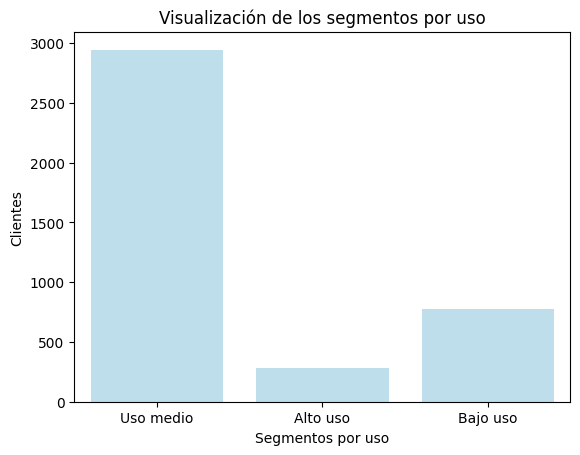

In [47]:

# Visualización de los segmentos por uso
#Sintaxis básica: sns.countplot(data=df, x='columna', hue='otra_columna', palette=['color1', 'color2'])
sns.countplot(data=user_profile, x="grupo_uso", color="skyblue", alpha=0.6)

plt.xlabel('Segmentos por uso')
plt.ylabel('Clientes')
plt.title('Visualización de los segmentos por uso')

plt.show()

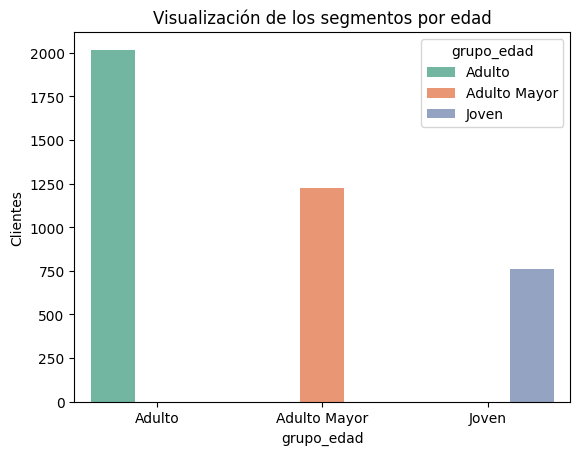

In [46]:
# Visualización de los segmentos por edad
#Sintaxis básica: sns.countplot(data=df, x='columna', hue='otra_columna', palette=['color1', 'color2'])
#sns.countplot(data=user_profile, x="grupo_edad", color="skyblue", alpha=0.6)
sns.countplot(data=user_profile, x="grupo_edad", hue="grupo_edad", palette="Set2")
#plt.xlabel('Segmentos por edad')
plt.ylabel('Clientes')
plt.title('Visualización de los segmentos por edad')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Durante la etapa de exploración y limpieza se identificaron algunos problemas de calidad en los datos.

En el dataframe users se detectó lo siguiente:

- La columna city presentaba un 11.7% de valores faltantes.
- La columna churn_date presentaba un 88.3% de valores faltantes.

En el dataframe usage se detectó lo siguiente:

- La columna date presentaba menos de un 1% de faltantes, el 0.1%, un porcentaje poco significativo para el análisis.
- La columna duration presentaba un 55.2% de valores faltantes.
- La columna length presentaba un 44.7% de valores faltantes.

Los valores faltantes en duration y length no representan errores de captura, sino que más bien obedecen al tipo de interacción registrada: para las llamadas únicamente se almacena la duración, mientras que para los mensajes se almacena la longitud.

Asimismo, se identificó una distribución asimétrica positiva (right-skewed) en las variables relacionadas con:

- Cantidad de mensajes por plan.
- Cantidad de llamadas por plan.
- Minutos consumidos en llamadas por cliente.

Esto indica que la mayoría de los usuarios presenta un consumo moderado, mientras que un grupo reducido concentra niveles de uso considerablemente superiores al promedio.

🔍 **Segmentos por Edad**

Se identificaron tres grupos principales:
- Jóvenes: menores de 30 años.
- Adultos: entre 30 y 59 años.
- Adultos mayores: 60 años o más.

El análisis muestra que la mayor parte de la base de clientes pertenece al segmento de adultos, mientras que se observa una ligera mayor participación entre los adultos mayores en el plan Premium.

📊 **Segmentos por Nivel de Uso**

Con base en el historial de llamadas y mensajes se clasificó a los usuarios en tres grupos:
- Bajo uso: menos de 5 llamadas y menos de 5 mensajes.
- Uso medio: menos de 10 llamadas y menos de 10 mensajes.
- Alto uso: usuarios que superan el umbral medio.
Los resultados muestran que la mayor parte de los clientes pertenece al segmento de uso medio durante el periodo analizado.

➡️ Todo lo anterior sugiere que: 

- Los clientes con mayor valor para la compañía son aquellos pertenecientes al segmento de uso medio, ya que potencialmente, generan mayores ingresos para la empresa.
- También existe una gran cantidad de usuarios del plan Básico cuyo nivel de uso supera los promedios observados. Este grupo representa una oportunidad para implementar estrategias de upselling.
- Se identificó un grupo reducido de usuarios con patrones de consumo significativamente superiores al promedio. Mientras que la mayoría de las llamadas tiene una duración aproximada de entre 10 y 18 minutos, algunos usuarios registran llamadas cercanas a 130–140 minutos, lo que evidencia comportamientos atípicos. Estos casos pueden corresponder a clientes de alto valor, usuarios corporativos o situaciones específicas que conviene analizar de forma individual para comprender su impacto en la rentabilidad del negocio.

💡 **Recomendaciones**

Con base en los resultados obtenidos, se proponen las siguientes acciones:
- Diseñar campañas de upselling dirigidas a usuarios del plan Básico con altos niveles de consumo para incentivar su migración al plan Premium.
- Crear planes diferenciados para clientes de alto uso, incorporando mayores beneficios en minutos y mensajes que favorezcan su permanencia y reduzcan el riesgo de cancelación.
- Implementar campañas de fidelización para el segmento de adultos, ya que representa la mayor proporción de la cartera de clientes.
- Analizar de manera específica a los usuarios con consumos extraordinariamente altos para determinar si requieren planes especializados o si representan oportunidades de negocio adicionales.
- Monitorear periódicamente la calidad de los datos, especialmente en la columna city, para mejorar la precisión de futuras segmentaciones geográficas y campañas comerciales.
- Incorporar variables adicionales, como ingresos por cliente (ARPU), antigüedad y cancelaciones, para construir modelos de segmentación más robustos y apoyar la toma de decisiones estratégicas.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que 
describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.

---

Link a repositorio público del proyecto: `https://github.com/ing-josedavid/sprint7-fp_telecom-analysis.git`